# Libraries and core functions

In [9]:
// For collections
import scala.collection.mutable
import scala.math.{pow, exp, tanh}
import scala.util.Random
import scala.util.boundary, boundary.break

// For calculations
import $ivy.`org.apache.commons:commons-math3:3.6.1`
import org.apache.commons.math3.analysis.function.{Atanh}
import org.apache.commons.math3.ode.{FirstOrderDifferentialEquations, FirstOrderIntegrator}
import org.apache.commons.math3.ode.sampling.{StepHandler, StepInterpolator}
import org.apache.commons.math3.ode.nonstiff.{ClassicalRungeKuttaIntegrator, DormandPrince853Integrator}
import org.apache.commons.math3.linear.{MatrixUtils, ArrayRealVector, Array2DRowRealMatrix, RealMatrix, RealVector}

// For reading files
import scala.io.Source
import java.io.File

// For Rust
import $ivy.`net.java.dev.jna:jna:5.14.0`

import com.sun.jna.{Native, Library}

// For display
import $ivy.`org.jfree:jfreechart:1.5.6`

import almond.display.Image

import org.jfree.chart.plot.{XYPlot, PlotOrientation}
import org.jfree.chart.axis.{LogAxis, NumberAxis}
import org.jfree.chart.renderer.xy.XYItemRenderer
import org.jfree.chart.{ChartFactory, JFreeChart}

import javax.imageio.ImageIO

import java.io.ByteArrayOutputStream
import org.jfree.data.xy.{DefaultXYDataset, XYSeries, XYSeriesCollection }
import org.jfree.chart.renderer.xy.XYLineAndShapeRenderer
import java.awt.image.BufferedImage
import java.awt.geom.{Ellipse2D, Rectangle2D}
import java.awt.{Color, Font, Shape, BasicStroke, Polygon, Stroke }
import javax.imageio.ImageIO

import scala.collection.mutable

import scala.math.{pow, exp, tanh}

import scala.util.Random

import scala.util.boundary, boundary.break

// For calculations

import $ivy.$                                       

import org.apache.commons.math3.analysis.function.{Atanh}

import org.apache.commons.math3.ode.{FirstOrderDifferentialEquations, FirstOrderIntegrator}

import org.apache.commons.math3.ode.sampling.{StepHandler, StepInterpolator}

import org.apache.commons.math3.ode.nonstiff.{ClassicalRungeKuttaIntegrator, DormandPrince853Integrator}

import org.apache.commons.math3.linear.{MatrixUtils, ArrayRealVector, Array2DRowRealMatrix, RealMatrix, RealVector}

// For reading files

import scala.io.Source

import java.io.File

// For Rust

import $ivy.$                            


import com.sun.jna.{Native, Library}

// For display

import $ivy.$                           


import almond.display.Image


import org.jfree.chart.plot.{XYPlot, PlotOrientation}

import org.jfree.chart.axis

## Display

https://developer.mozilla.org/en-US/docs/Web/CSS/Reference/Properties/image-rendering

In [2]:

def display_image(im: BufferedImage) = {
  val baos = new ByteArrayOutputStream()
  ImageIO.write(im, "png", baos)
  almond.display.Image(baos.toByteArray)
}

enum ImageRenderingType {
  case auto, pixelated
}

def display_images_html(
  ims: Array[BufferedImage],
  renderingType: ImageRenderingType = ImageRenderingType.auto,
  padding: Int = 20,
  width: Int = 400,
  height: Int = 400,
  text: String = ""
) = {
  val imagesHtml = ims.zipWithIndex.map { case (img, idx) =>
      val out = new java.io.ByteArrayOutputStream()
      javax.imageio.ImageIO.write(img, "png", out)
      val b64 = java.util.Base64.getEncoder.encodeToString(out.toByteArray)
      s"""<img src="data:image/png;base64,$b64"
          style="width:${width}px; 
                 height:${height}px; 
                 image-rendering:${renderingType.toString()}; 
                 display:block;
                 background:#1e1e1e;
                 border-radius: 6px;
                 padding: ${padding}"/>"""
    }.mkString

  // Стиль шапки (только если текст не пустой)
  val headerHtml = if (text.nonEmpty) 
    s"""<div style="text-align:left; color:rgba(146, 168, 255, 0.5); font-size:18px; font-weight:500; 
                    margin-bottom:6px; line-height:1.4; padding: 0px 0px 2px 8px; border-radius:2px">
          $text
        </div>""" 
  else ""

  // Сетка изображений
  val gridStyle = 
    s"display: grid; " +
    s"grid-template-columns: repeat(auto-fill, minmax(${width}px, 1fr)); " +
    s"gap: ${padding}px; " +
    s"justify-items: center; " +
    s"align-items: center;"

  // Внешний контейнер с тёмным фоном
  val containerStyle = 
    s"background: #0f0f0f; " +          // Глубокий тёмный фон
    s"padding: ${padding}px; " +
    s"font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; " +
    s"border-radius: 2px; " +
    s"padding: 4px 12px 4px 12px; " +
    s"box-shadow: 0 4px 10px rgba(0,0,0,0.6);"
    
  almond.display.Html(
    s"""<div style="$containerStyle">
          $headerHtml
          <div style="$gridStyle">$imagesHtml</div>
        </div>"""
  )
}

defined function display_image
defined class ImageRenderingType
defined function display_images_html

In [3]:
def circle(r: Double): Shape = new Ellipse2D.Double(-r, -r, 2 * r, 2 * r)
def square(r: Double): Shape = new Rectangle2D.Double(-r, -r, 2 * r, 2 * r)
def triangle(r: Double): Shape = {
  val ri = r.toInt
  new Polygon(Array(0, ri, -ri), Array(-ri, ri, ri), ri)
}

def solid(width: Float = 2f): Stroke = new BasicStroke(width, BasicStroke.CAP_ROUND, BasicStroke.JOIN_ROUND)
def dashed(width: Float = 2f, dash: Float = 8f, gap: Float = 4f): Stroke = 
  new BasicStroke(width, BasicStroke.CAP_ROUND, BasicStroke.JOIN_ROUND, 0f, Array(dash, gap), 0f)
def dotted(width: Float = 2f): Stroke = 
  new BasicStroke(width, BasicStroke.CAP_ROUND, BasicStroke.JOIN_ROUND, 0f, Array(2f, 4f), 0f)

enum DrawMode:
  case LinesOnly, PointsOnly, LinesAndPoints

case class SeriesStyle(
  color: Color = Color.BLACK,
  shape: Shape = circle(4),
  lineWidth: Float = 2f,
  Stroke: Stroke = solid(2f),
  drawMode: DrawMode = DrawMode.LinesAndPoints,
  shapeFilled: Boolean = true,
  // Optional: per-series renderer hints (e.g., for transparency)
  rendererHints: Map[AnyRef, AnyRef] = Map.empty
)


def display_chart(
  chart: JFreeChart,
  styles: Map[String, SeriesStyle] = Map.empty,
  defaultStyle: SeriesStyle = SeriesStyle(), // fallbacm for unstyled series
  backgroundColor: Color = Color.WHITE,
  gridlineColor: Color = new Color(220, 220, 220, 120),
  width: Int = 1000,
  height: Int = 600
) = {
  val plot = chart.getPlot().asInstanceOf[XYPlot]
  val renderer = plot.getRenderer().asInstanceOf[XYLineAndShapeRenderer]
  val dataset = plot.getDataset().asInstanceOf[XYSeriesCollection]

  // Global styling
  plot.setBackgroundPaint(backgroundColor)
  plot.setDomainGridlinePaint(gridlineColor)
  plot.setRangeGridlinePaint(gridlineColor)

  // Improve fonts
  val axisFont = new Font("Arial", Font.PLAIN, 12)
  val labelFont = new Font("Arial", Font.BOLD, 14)
  plot.getDomainAxis().setLabelFont(labelFont)
  plot.getRangeAxis().setLabelFont(labelFont)
  plot.getDomainAxis().setTickLabelFont(axisFont)
  plot.getRangeAxis().setTickLabelFont(axisFont)
  chart.getTitle().setFont(new Font("Arial", Font.BOLD, 16))

  // Apply per-series styles by NAME
  val seriesCount = dataset.getSeriesCount()
  for (i <- 0 until seriesCount) {
    val series = dataset.getSeries(i)
    val seriesName = series.getKey.toString
    val style = styles.getOrElse(seriesName, defaultStyle)

    // Set visual properties
    renderer.setSeriesPaint(i, style.color)
    renderer.setSeriesShape(i, style.shape)
    renderer.setSeriesStroke(i, style.Stroke)
    renderer.setSeriesShapesFilled(i, style.shapeFilled)

    // Draw mode logic
    style.drawMode match {
      case DrawMode.LinesOnly       => renderer.setSeriesLinesVisible(i, true);  renderer.setSeriesShapesVisible(i, false)
      case DrawMode.PointsOnly      => renderer.setSeriesLinesVisible(i, false); renderer.setSeriesShapesVisible(i, true)
      case DrawMode.LinesAndPoints  => renderer.setSeriesLinesVisible(i, true);  renderer.setSeriesShapesVisible(i, true)
    }
  }

  // Render image
  val img = chart.createBufferedImage(width, height, BufferedImage.TYPE_INT_ARGB, null)
  val baos = new ByteArrayOutputStream()
  ImageIO.write(img, "png", baos)
  almond.display.Image(baos.toByteArray)
}

defined function circle
defined function square
defined function triangle
defined function solid
defined function dashed
defined function dotted
defined class DrawMode
defined class SeriesStyle
defined function display_chart

# Hopfield

https://en.wikipedia.org/wiki/Hopfield_network#Convergence_properties_of_discrete_and_continuous_Hopfield_networks

Лучше в статье:
https://pmc.ncbi.nlm.nih.gov/articles/PMC346238/

https://commons.apache.org/proper/commons-math/javadocs/api-3.6.1/org/apache/commons/math3/linear/ArrayRealVector.html

## Theory

Классическая модель сети Хопфилда состоит из состояния нейронов - $x$ - вектор длины N и весов - матрицы связей от нейрона $i$ к нейрону $j$ - $T$ - размера N на N. Важно, что матрица весов $T$ непрерывна. Учится на паттернах $p^k$ - векторах длины N.

Нейроны могут хранить как двоичную информацию, так и вещественные числа, в зависимости от выбора динамики и правила обучения.

**Для дискретного случая** и бинарного паттерна с компонентами из $\{0,1\}$ имеем уравнение вида:
$$
x_i = \begin{cases} 1 \quad if \ \sum_{j \neq i} T_{ij} \ x_j \geq \theta_i, \\ 0 \quad otherwise. \end{cases}
$$
или так ($T_{ii} = 0$)
$$
x_i = \begin{cases} 1 \quad if \ \langle T_{row=i}, x \rangle \geq \theta_i, \\ 0 \quad otherwise. \end{cases}
$$
где $\theta_i$ - погрешность активации.

Причём, можно заменить $\{0,1\}$ на $\{-1,1\}$ в зависимости от правил обучения.

Динамика может быть асинхронная (произвольная активация или наложен порядок активации) и синхронная (одновременная активация - нереалистично).

**Для непрерывного случая** имеем дифференциальное уравнение вида:

$$
\tau_f \frac{dx_i}{dt} = \sum\limits_{j=1}^{N_f} T_{ij} V_j - x_i + I_i
$$

T - матрица весов связей, $V_i$ = функция активации $g(x_i)=\frac{\partial L_{x}}{\partial x_{i}}$, где $L$ - функция от энергии.

Отсюда по формулам Эйлера можно вывести изменение $x_i$:

$$
\frac{dx_i}{dt} = \langle T_{row=i}, V \rangle - x_i + I_i
$$

$$
x = x + \tau_f \frac{dx}{dt}
$$

Есть также современная динамика с использованием скрытых слоёв, но здесь мы её не рассматриваем.

---

### Обучение весов

**Обучение по правилу Хэбба для дискретной динамики**
Для компонент паттернов $p_i$ взятых из $\{0,1\}$:
$$
T_{ij}=\sum_k (2p_i^k-1)(2p_j^k-1)
$$
Для $\{-1,1\}$:
$$
T_{ij}=\frac{1}{n}\sum_{k=1}^n p_i^k p_j^k
$$
Можно заметить, что это внешнее произведение. Важно, что сама матрица весов $T$ непрерывна и на диагонали всегда 0 - $T_{ii} = 0$.

Также было замечено, что не хватает нормализации весов. Можно попробовать добавить её.


Хэбб и Сторки обучаются за одну итерацию.

**Обучение Сторки для дискретной и непрерывной динамики**

Веса зануляются.

Затем для каждой пары паттернов
$
w_{ij}^{new}=w_{ij}^{old} + \frac{1}{N}(x_ix_j - x_ih_j - x_jh_i
$

где
$
h_i = \sum w_{ik}x_k
$



**Скоростной градиент** для непрерывной динамики.

Непрерывная динамика сети Хопфилда
$$
\tau_f \frac{dx_i}{dt} = \sum\limits_{j=1}^{N_f} T_{ij} V_j - x_i + I_i
$$
рассматривается в виде динамической системы $\dot{x} = \omega(x,\theta,t)$, где $\theta$ - веса матрицы $T$.

Скоростной градиент имеет вид
$$
\frac{d\theta}{dt} = -\Gamma \nabla_{\theta}{\omega(x,\theta,t)}
$$
$$
\omega(x,\theta,t) = \frac{dQ}{dt}
$$

Функционал $Q$

локальный $Q = Q(x(t), t)$

интегральный $Q = \int\limits_0^t R(x(s),\theta(s),s) ds$

Можно заметить, что в нашем случае система адаптивная, где устойчивость достигается за счёт настройки только внутренних параметров.

## Loading Images

Загрузим изображения

In [19]:
import javax.imageio.ImageIO
import java.io.File
import java.awt.image.BufferedImage

def get_images(images_count: Int, folder: String, file_name: String): Array[BufferedImage] = {
  val images: Array[BufferedImage] = new Array[BufferedImage](images_count)

  for (i <- 0 until images_count) {
    val image = ImageIO.read(new File(s"data/hopfield/$folder/$file_name$i.png"))
    println(s"Image loaded: ${image.getWidth}x${image.getHeight} pixels")
    images(i) = image
  }
  return images
}

import javax.imageio.ImageIO

import java.io.File

import java.awt.image.BufferedImage


defined function get_images

In [20]:
val images = get_images(3, "test", "f")
val images_numbers = get_images(10, "numbers", "")

display_images_html(images, ImageRenderingType.pixelated, 10, 100, 100, "Картинки")
display_images_html(images_numbers, ImageRenderingType.pixelated, 10, 100, 100, "Цифры")

Image loaded: 8x8 pixels
Image loaded: 8x8 pixels
Image loaded: 8x8 pixels
Image loaded: 6x7 pixels
Image loaded: 6x7 pixels
Image loaded: 6x7 pixels
Image loaded: 6x7 pixels
Image loaded: 6x7 pixels
Image loaded: 6x7 pixels
Image loaded: 6x7 pixels
Image loaded: 6x7 pixels
Image loaded: 6x7 pixels
Image loaded: 6x7 pixels


Картинки

Цифры

images: Array[BufferedImage] = Array(
  BufferedImage@e193687: type = 6 ColorModel: #pixelBits = 32 numComponents = 4 color space = java.awt.color.ICC_ColorSpace@5112e0c transparency = 3 has alpha = true isAlphaPre = false ByteInterleavedRaster: width = 8 height = 8 #numDataElements 4 dataOff[0] = 3,
  BufferedImage@6b9a5419: type = 6 ColorModel: #pixelBits = 32 numComponents = 4 color space = java.awt.color.ICC_ColorSpace@5112e0c transparency = 3 has alpha = true isAlphaPre = false ByteInterleavedRaster: width = 8 height = 8 #numDataElements 4 dataOff[0] = 3,
  BufferedImage@46ce2af7: type = 6 ColorModel: #pixelBits = 32 numComponents = 4 color space = java.awt.color.ICC_ColorSpace@5112e0c transparency = 3 has alpha = true isAlphaPre = false ByteInterleavedRaster: width = 8 height = 8 #numDataElements 4 dataOff[0] = 3
)
images_numbers: Array[BufferedImage] = Array(
  BufferedImage@4c32f96e: type = 6 ColorModel: #pixelBits = 32 numComponents = 4 color space = java.awt.color.ICC_ColorSp

## Images Encoding

Теперь напишем Кодировщик для картинок. Нужно преобразовывать изображение в разные вектора с данными. Для Хэбба в вектор с бинарными данными, так как стандартное правило Хебба поддерживает только бинарные вектора.

Если будет 24 бита на цвет пикселя, то мы не теряем никакой информации, но тогда получим вектор из 24 * 8 * 8 элементов = 1536. 

Правило обычного кодирования просто записывает биты в вектора.

Можно закодировать иначе: задать правило кодирования пикселя на каждую шестнадцатеричную компоненту RRGGBB:
> если больше 7, тогда 1, иначе 0

Тогда выйдет 6 бит на цвет пикселя, но часть информации будет утеряна. Получим вектор из 6 * 8 * 8 элементов = 384.

Или в непрерывном случае просто записываем цвет Int как он есть в Double

Ошибка добавляется к компонентам цвета по отдельности.

https://commons.apache.org/proper/commons-math/userguide/linear.html

In [21]:
// Colors are represented as Int objects. 
// The three components red, green, and blue 
// are "packed" together into one integer. 
// Each component has 8 bits, and therefore 
// can have a value between 0 and 255. 
// The packed color is a 32-bit integer, 
// whose bits look like this:
// tttt tttt rrrr rrrr gggg gggg bbbb bbbb
// TT RR GG BB in 16

trait IColorEncoder {
  val move: Int
  val rand: Random

  def encode_color(index: Int, color: Int, target: ArrayRealVector, err_b: Double): Unit
  def decode_color(index: Int, target: ArrayRealVector): Int
}

class EncoderColorBits extends IColorEncoder {
  val move: Int = 24
  val rand: Random = new Random

  def encode_color(index: Int, color: Int, target: ArrayRealVector, err_b: Double): Unit = {
    var t = target
    val h = index
    var c = color
    // Give error to every xxxx component of "rrrr rrrr gggg gggg bbbb bbbb"
    val err = () => { ((rand.nextDouble() - 0.5) * 2.0 * err_b).toInt }
    c += err() + (err() << 4) + (err() << 8) + (err() << 12) + (err() << 16) + (err() << 20)

    for (g <- 0 until move) {
      val value = if (((c >> g) & 1) == 1) 1.0 else -1.0
      t.setEntry(h + g, value)
    }
  }

  def decode_color(index: Int, target: ArrayRealVector): Int = {
    var t = target
    val h = index
    var c = 0
    for (g <- 0 until move) {
      val bit = if (t.getEntry(h + g) > 0.0) 1 else 0
      c = c | (bit << g)
    }
    c
  }
}

class EncoderColorMono extends IColorEncoder {
  val move: Int = 1
  val rand: Random = new Random

  def encode_color(index: Int, color: Int, target: ArrayRealVector, err_b: Double): Unit = {
    val t = target
    val h = index
    val c = color
    // Give error to every xxxx component of "rrrr rrrr gggg gggg bbbb bbbb"
    val r = ((rand.nextDouble() - 0.5) * 2.0 * err_b).toInt
    if ((-c.toDouble / 16777216.0).toInt + r > 0) {
      t.setEntry(h, -1.0)  
    }
    else {
      t.setEntry(h, 1.0)      
    }
  }

  def decode_color(index: Int, target: ArrayRealVector): Int = {
    val t = target
    val h = index
    val c = target.getEntry(h)
    if (c > 0.0) {
      return 16777215
    }
    else {
      return 0
    }
  }
}

def encode_images(images: Array[BufferedImage], width: Int, height: Int, encoder: IColorEncoder, err: Double): Array[ArrayRealVector] = {
  val images_count = images.length
  val pattern_length = encoder.move * height * width
  val patterns = new Array[ArrayRealVector](images_count)

  for (k <- 0 until images_count) {
    val v = ArrayRealVector(pattern_length)
    val im = images(k)
    var h = 0
    for (i <- 0 until width) {
      for (j <- 0 until height) {
        val c = im.getRGB(i,j)
        encoder.encode_color(h, c, v, err)
        h += encoder.move
      }
    }
    patterns(k) = v
  }
  patterns
}

def convert_to_image_from_array(vector: ArrayRealVector, width: Int, height: Int, encoder: IColorEncoder): BufferedImage = {
  val image = new BufferedImage(width, height, BufferedImage.TYPE_INT_RGB)
  
  var h: Int = 0
  for (i <- 0 until width) {
    for (j <- 0 until height) {
      var c = encoder.decode_color(h, vector)
      image.setRGB(i, j, c)
      h += encoder.move
   }
  }

  image
}

def display_patterns(patterns: Array[ArrayRealVector], width: Int, height: Int, encoder: IColorEncoder, text: String = "") = {
  val returned_images = new Array[BufferedImage](patterns.length)
  for (i <- 0 until patterns.length) {
    returned_images(i) = convert_to_image_from_array(patterns(i), width, height, encoder) 
  }
  display_images_html(returned_images, ImageRenderingType.pixelated, 10, 100, 100, text)
}

val enc_b = new EncoderColorBits()
val enc_m = new EncoderColorMono()

defined trait IColorEncoder
defined class EncoderColorBits
defined class EncoderColorMono
defined function encode_images
defined function convert_to_image_from_array
defined function display_patterns
enc_b: EncoderColorBits = ammonite.$sess.cmd21$Helper$EncoderColorBits@3f47543f
enc_m: EncoderColorMono = ammonite.$sess.cmd21$Helper$EncoderColorMono@330ffcd4

Посмотрим на закодированные изображения.

In [73]:
val width = 8
val height = 8
val state_size_bits = enc_b.move * width * height

val width_m = 6
val height_m = 7
val state_size_mono = enc_m.move * width_m * height_m

// Кодирование картинок
val patterns = encode_images(images, width, height, enc_b, 0.0)
val patterns_error = encode_images(images, width, height, enc_b, 1.4)

// Кодирование цифр
val patterns_numbers = encode_images(images_numbers, width_m, height_m, enc_m, 0.0)
val patterns_numbers_error = encode_images(images_numbers, width_m, height_m, enc_m, 1.25)

// Раскодирование
display_patterns(patterns, width, height, enc_b, "Картинки")
display_patterns(patterns_error, width, height, enc_b, "Картинки с ошибкой")

display_patterns(patterns_numbers, width_m, height_m, enc_m, "Моно цифры")
display_patterns(patterns_numbers_error, width_m, height_m, enc_m, "Моно цифры с ошибкой")

Картинки

Картинки с ошибкой

Моно цифры

Моно цифры с ошибкой

width: Int = 8
height: Int = 8
state_size_bits: Int = 1536
width_m: Int = 6
height_m: Int = 7
state_size_mono: Int = 42
patterns: Array[ArrayRealVector] = Array(
  {-1; -1; -1; -1; -1; -1; -1; -1; -1; 1; 1; 1; 1; 1; 1; -1; 1; 1; 1; 1; 1; 1; 1; 1; -1; -1; -1; -1; -1; -1; -1; -1; -1; 1; 1; 1; 1; 1; 1; -1; 1; 1; 1; 1; 1; 1; 1; 1; -1; -1; -1; -1; -1; -1; -1; -1; -1; 1; 1; 1; 1; 1; 1; -1; 1; 1; 1; 1; 1; 1; 1; 1; -1; -1; -1; -1; -1; -1; -1; -1; -1; 1; 1; 1; 1; 1; 1; -1; 1; 1; 1; 1; 1; 1; 1; 1; -1; -1; -1; -1; -1; -1; -1; -1; -1; 1; 1; 1; 1; 1; 1; -1; 1; 1; 1; 1; 1; 1; 1; 1; -1; -1; -1; -1; -1; -1; -1; -1; -1; 1; 1; 1; 1; 1; 1; -1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; -1; 1; 1; 1; 1; 1; 1; -1; 1; 1; -1; 1; -1; -1; -1; -1; -1; -1; -1; -1; -1; -1; -1; -1; -1; -1; -1; -1; -1; 1; 1; 1; 1; 1; 1; -1; 1; 1; 1; 1; 1; 1; 1; 1; -1; -1; -1; -1; -1; -1; -1; -1; -1; 1; 1; 1; 1; 1; 1; -1; 1; 1; 1; 1; 1; 1; 1; 1; -1; -1; -1; -1; -1; -1; -1; -1; -1; 1; 1; 1; 1; 1; 1; -1; 1; 1; 1; 1; 1; 1; 1; 1; -1; -1; -1; -1

# Model

Теперь зададим модель классической дискретной сети Хопфилда с правилом обучения по Хэббу:

$$
T_{ij}=\sum_k (2p_i^k-1)(2p_j^k-1)
$$

$$
x_i = \begin{cases} 1 \quad if \ \langle T_{row=i}, x \rangle \geq \theta_i, \\ 0 \quad otherwise. \end{cases}
$$

И по скоростному градиенту:

In [4]:
class HopfieldDiscreet(n: Int) {
  val x = new ArrayRealVector(n)
  val t = new Array2DRowRealMatrix(n, n)

  var threshold = 0.0

  def set_threshold(threshold: Double): HopfieldDiscreet = {
    this.threshold = threshold
    this
  }

  def get_state_size() = {
    n
  }
  
  def step_sync() = {
    for (i <- 0 until n) {
      val sc =
        if (t.getRowVector(i).dotProduct(x) > threshold) 
          1.0
        else
          0.0
      x.setEntry(i, sc)
    }
  }

  def step_async() = {
    val k = (Random.nextDouble() * n).toInt
    val sc =
      if (t.getRowVector(k).dotProduct(x) > threshold) 
        1.0
      else 
        0.0
    x.setEntry(k, sc)
  }

  def set_weights(w: Array2DRowRealMatrix): HopfieldDiscreet = {
    for (i <- 0 until n; j <- 0 until n) {
      t.setEntry(i, j, w.getEntry(i, j))
    }
    this
  }

  def set_x(new_x: ArrayRealVector): HopfieldDiscreet = {
    for (i <- 0 until n) {
      x.setEntry(i, new_x.getEntry(i))
    }
    this
  }

  def get_x(): ArrayRealVector = {
    x.copy
  }
}

defined class HopfieldDiscreet

In [5]:
class HopfieldDynamicODE(n: Int) extends FirstOrderDifferentialEquations {
  val y = new ArrayRealVector(n) // Activated x

  var activation: (x: Double) => Double = null
  var beta: Double = 0.0

  var W: Array2DRowRealMatrix = null
  var b: ArrayRealVector = null

  def set_data(
    W: Array2DRowRealMatrix, b: ArrayRealVector,
  ): HopfieldDynamicODE = {
    this.W = W
    this.b = b
    this
  }

  def set_data(
    activation: (x: Double) => Double,
    beta: Double
  ): HopfieldDynamicODE = {
    this.activation = activation
    this.beta = beta
    this
  }

  override def getDimension: Int = n

  override def computeDerivatives(t: Double, state: Array[Double], dState: Array[Double]): Unit = {
    // Активация состояний x
    for (i <- 0 until n) {
      val activatedXi = activation(state(i))
      y.setEntry(i, activatedXi)
    }

    for (i <- 0 until n) {
      // Строка W
      val wi = W.getRowVector(i)
      val wdpy = wi.dotProduct(y)

      val xi = state(i)
      val bi = b.getEntry(i)

      // dxi/dt = <w_row=i, y_row=i> - beta * xi + bi
      dState(i) = wdpy - beta * xi + bi
    }
  }
}

class HopfieldDynamic(n: Int) {
  val ode = new HopfieldDynamicODE(n)
  val state = new Array[Double](ode.getDimension())
  
  var t: Double = 0.0
  var dt: Double = 0.0
  var integrator: FirstOrderIntegrator = null
  
  def get_state_size() = {
    n
  }

  def set_time(t: Double): HopfieldDynamic = {
    this.t = t
    this
  }

  def set_integrator(integrator: FirstOrderIntegrator, dt: Double): HopfieldDynamic = {
    this.integrator = integrator
    this.dt = dt
    this
  }

  def set_randomised_state(r1: Double, r2: Double): HopfieldDynamic = {
    val rng = new Random()
    val r = r2 - r1
    for (i <- 0 until n) {
      state(i) = r1 + r * rng.nextDouble()
    }
    this
  }
  
  def set_state(x: ArrayRealVector): HopfieldDynamic = {
    for (i <- 0 until n) {
      state(i) = x.getEntry(i)
    }
    this
  }

  def integrate(t: Double) = {    
    // integrate(FirstOrderDifferentialEquations equations, double t0, double[] y0, double t, double[] y)
    // Parameters:
    //  equations - differential equations to integrate
    //  t0 - initial time
    //  y0 - initial value of the state vector at t0
    //  t - target time for the integration (can be set to a value smaller than t0 for backward integration)
    //  y - placeholder where to put the state vector at each successful step (and hence at the end of integration), can be the same object as y0
    integrator.integrate(ode, this.t, state, this.t + t, state)
    this.t += t
  }

  def get_x(): ArrayRealVector = {
    new ArrayRealVector(state.clone)
  }
}

defined class HopfieldDynamicODE
defined class HopfieldDynamic

In [6]:
class HopfieldHebb(n: Int) {
  val weights = new Array2DRowRealMatrix(n, n)

  def get_state_size() = {
    n
  }

  def fit_0_1(p: Array[ArrayRealVector]): Unit = {
    val pl = p.length 
    if (pl == 0 || p(0).getDimension != n) {
      println("Didn't fit, because dimensions are bad")
      return
    }
    
    for (i <- 0 until n) {
      for (j <- 0 until n) {
        val v = (0 until pl).map(k =>
            val pk = p(k)
            (2 * pk.getEntry(i) - 1) * (2 * pk.getEntry(j) - 1)
          ).sum
        weights.setEntry(i, j, v / pl) 
      }
      weights.setEntry(i, i, 0)
    }
  }

  def fit_m1_1(p: Array[ArrayRealVector]): Unit = {
    val pl = p.length 
    if (pl == 0 || p(0).getDimension != n) {
      println("Didn't fit, because dimensions are bad")
      return
    }
    
    for (i <- 0 until n) {
      for (j <- 0 until n) {
        val v = (0 until pl).map(k =>
            val pk = p(k)
            pk.getEntry(i) * pk.getEntry(j)
          ).sum
        weights.setEntry(i, j, v / pl) 
      }
      weights.setEntry(i, i, 0)
    }
  }
}

defined class HopfieldHebb

In [10]:
class HopfieldStorkey(n: Int) {
  val weights = new Array2DRowRealMatrix(n, n)

  def get_state_size() = {
    n
  }

  def fit(patterns: Array[ArrayRealVector], steps_count: Int = 1): Unit = {
    val pl = patterns.length 
    if (pl == 0 || patterns(0).getDimension != n) {
      println("Didn't fit, because dimensions are bad")
      return
    }
    for (i <- 0 until n; j <- 0 until n) {
      weights.setEntry(i, j, 0.0)
    }

    val h = new ArrayRealVector(n)
    
    for (t <- 0 until steps_count) {
    for (mu <- 0 until pl) {
      val p = patterns(mu)
      for (i <- 0 until n) {
        // hi = W_{row=m} \cdot pm
        val wi = weights.getRowVector(i)
        val hi = wi.dotProduct(p)
        h.setEntry(i, hi)
      }
      for (i <- 0 until n; j <- 0 until n) {
        val wij = weights.getEntry(i, j)
        val xi = p.getEntry(i)
        val xj = p.getEntry(j)
        val hi = h.getEntry(i)
        val hj = h.getEntry(j)
        val v = 1.0 / n * (xi * xj - xi * hj - xj * hi)
        weights.setEntry(i, j, wij + v)
      }
    }
    }
  }
}

defined class HopfieldStorkey

In [11]:
class HopfieldPseudo(n: Int) {
  val weights = new Array2DRowRealMatrix(n, n)

  def get_state_size() = {
    n
  }

  def fit(patterns: Array[ArrayRealVector], steps_count: Int = 1): Unit = {
    val pl = patterns.length 
    if (pl == 0 || patterns(0).getDimension != n) {
      println("Didn't fit, because dimensions are bad")
      return
    }

    for (i <- 0 until n; j <- 0 until n) {
      weights.setEntry(i, j, 0.0)
    }

    val Q = new Array2DRowRealMatrix(pl,pl)
    
    for (t <- 0 until steps_count) {

    // Calculating Q
    for (v <- 0 until pl; m <- 0 until pl) {
      val pi = patterns(v)
      val pj = patterns(m)
      Q.setEntry(v, m, pi.dotProduct(pj))
    }

    println(f"${Q}")

    val Qi = MatrixUtils.inverse(Q)
    
    for (v <- 0 until pl; m <- 0 until pl) {
      val ksiv = patterns(v)
      val ksim = patterns(m)
      for (i <- 0 until n; j <- 0 until n) {
        val ki = ksiv.getEntry(i)
        val kj = ksiv.getEntry(j)
        weights.addToEntry(i, j, ki * Qi.getEntry(v, m) * kj)
      }
    }

    val c = 1.0 / n
    for (i <- 0 until n; j <- 0 until n) {
      weights.multiplyEntry(i, j, c)
    }
    }
  }
}

defined class HopfieldPseudo

In [12]:
class HopfieldNoise(a: Double, lambda: Double, w: Double, delta: Double) {
  def noise(t: Double, x: Double): Double = {
      x + a * (math.exp(-lambda * t) + delta) * math.sin(w * t)
  }
}

def get_randomised_noise(
  p: Int, 
  a: Double, lambda: Double, delta: Double, w: Double, 
  er_a: Double, er_l: Double, er_d: Double, er_w: Double
): HopfieldNoise = {
  val rng = new Random()
  
  val n_a = a + rng.nextDouble() * er_a * p
  val n_lambda = lambda + rng.nextDouble() * er_l * p
  val n_w = w + rng.nextDouble() * er_w * p
  val n_delta = delta + rng.nextDouble() * er_d * p
  
  HopfieldNoise(n_a, n_lambda, n_w, n_delta)
}

defined class HopfieldNoise
defined function get_randomised_noise

In [217]:
case class HopfieldVelgradState(
  weights: Array2DRowRealMatrix,  // [n × n]
  bias: Array2DRowRealMatrix,     // [1 × n] (строка)
  x: Array2DRowRealMatrix         // [p × n]
)

object HopfieldVelgradState {
  
  @inline def pack(s: HopfieldVelgradState): Array[Double] = {
    val w = s.weights.getData.flatten  // [n x n], row-major
    val b = s.bias.getData.flatten     // [n]
    val x = s.x.getData.flatten        // [p x n], row-major
    w ++ b ++ x
  }

  @inline def packTo(arr: Array[Double], s: HopfieldVelgradState, n: Int, p: Int): Unit = {
    var pos = 0
    
    // === weights [n × n], row-major ===
    val wData = s.weights.getData  // Array[Array[Double]]
    var i = 0
    while (i < n) {
      val row = wData(i)
      var j = 0
      while (j < n) {
        arr(pos) = row(j)
        pos += 1
        j += 1
      }
      i += 1
    }
    
    // === bias [1 × n] ===
    val bData = s.bias.getData
    i = 0
    while (i < n) {
      arr(pos) = bData(0)(i)  // bias хранится как строка
      pos += 1
      i += 1
    }
    
    // === x [p × n], row-major ===
    val xData = s.x.getData
    i = 0
    while (i < p) {
      val row = xData(i)
      var j = 0
      while (j < n) {
        arr(pos) = row(j)
        pos += 1
        j += 1
      }
      i += 1
    }
  }
  
  @inline def unpack(data: Array[Double], n: Int, p: Int): HopfieldVelgradState = {
    val wSize = n * n
    val bSize = n
    val xSize = p * n

    // Извлекаем подмассивы (без .toArray — slice уже возвращает Array)
    val wData = data.take(wSize)                    
    val bData = data.slice(wSize, wSize + bSize)    
    val xData = data.drop(wSize + bSize).take(xSize)
  
    // Восстанавливаем 2D-массивы для конструктора Array2DRowRealMatrix
    val wData2d = Array.tabulate(n)(i => wData.slice(i * n, (i + 1) * n))       // [n × n]
    val bData2d = Array(bData)                                                  // [1 x n]
    val xData2d = Array.tabulate(p)(i => xData.slice(i * n, (i + 1) * n))       // [p × n]
    
    HopfieldVelgradState(
      weights = new Array2DRowRealMatrix(wData2d, false),
      bias    = new Array2DRowRealMatrix(bData2d, false),
      x       = new Array2DRowRealMatrix(xData2d, false)
    )
  }
}

class HopfieldVelgradODE(p: Int, n: Int) extends FirstOrderDifferentialEquations {
  val dW = new Array2DRowRealMatrix(n, n)   // [n × n]
  val db = new Array2DRowRealMatrix(1, n)   // [1 × n]
  val dX = new Array2DRowRealMatrix(p, n)  // [p × n]
  
  var W: Array2DRowRealMatrix = null
  var b: Array2DRowRealMatrix = null
  var x: Array2DRowRealMatrix = null

  val y = new Array2DRowRealMatrix(p, n) // Activated x

  var activation: (x: Double) => Double = null
  var deactivation: (x: Double) => Double = null
  var P = new Array2DRowRealMatrix(p, n)
  var deacP = new Array2DRowRealMatrix(p, n)
  var actP = new Array2DRowRealMatrix(p, n)
  var noise: Array[Array[HopfieldNoise]] = null
  
  var gammaW: Double = 0.0
  var gammaI: Double = 0.0 
  var alpha: Double = 0.0
  var beta: Double = 0.0

  def set_data(
    noise: Array[Array[HopfieldNoise]],
    activation: (x: Double) => Double, deactivation: (x: Double) => Double,
    gammaW: Double, gammaI: Double, alpha: Double, beta: Double,
  ): HopfieldVelgradODE = {
    this.noise = noise
    this.activation = activation
    this.deactivation = deactivation
    this.gammaW = gammaW
    this.gammaI = gammaI
    this.alpha = alpha
    this.beta = beta

    this
  }
  
  def set_patterns(patterns: Array[ArrayRealVector]) = {
    for (i <- 0 until p) {
      val pattern = patterns(i)
      for (j <- 0 until n) {
        P.setEntry(i, j, pattern.getEntry(j))
        deacP.setEntry(i, j, deactivation(pattern.getEntry(j)))
        actP.setEntry(i, j, activation(pattern.getEntry(j)))
      }
    }
  }

  override def getDimension: Int = n * n + n + p * n
  
  override def computeDerivatives(t: Double, state: Array[Double], dState: Array[Double]): Unit = {
    val s = HopfieldVelgradState.unpack(state, n, p)
    W = s.weights
    b = s.bias
    x = s.x

    for (i <- 0 until n; j <- 0 until n) dW.setEntry(i, j, 0.0)
    for (i <- 0 until n) db.setEntry(0, i, 0.0)
    for (i <- 0 until p; j <- 0 until n) dX.setEntry(i, j, 0.0)
    
    // Активация состояний x
    activate_x()

    // Динамика x
    for (k <- 0 until p) {
      // x и y фиксированы
      val xk = x.getRowVector(k)
      val yk = y.getRowVector(k)
      for (i <- 0 until n) {
        // Фиксируем строку W
        val wi = W.getRowVector(i)
    
        // На активации xi
        val wdpy = wi.dotProduct(yk)
    
        val xki = xk.getEntry(i)
        val bi = b.getEntry(0, i)
    
        // dxki/dt = <w_row=i, y_row=i> - beta * xki + bi
        dX.setEntry(k, i, wdpy - beta * xki + bi)
      }
    }

    // Вычисляем зашумленные активированные состояния
    noise_y(t)
    val noisyY = y
    
    // Агрегируем градиенты по всем паттернам
    for (mu <- 0 until p) {
      val xm = deacP.getRowMatrix(mu) // [1 × n]
      val ym = noisyY.getRowMatrix(mu) // [1 × n]

      // r = W·ymᵀ - xm + b  →  [1 × n]
      val r = rmu(xm, ym)

      // ∇W = r·yᵀ  →  [n × n]
      val gradW = r.transpose().multiply(ym).transpose()

      // ∇b = r  →  [n]
      val gradB = r

      // Накопление градиентов W
      for (i <- 0 until n; j <- 0 until n) {
        dW.addToEntry(i, j, gradW.getEntry(i, j) / p)
      }
      // Накопление градиентов b
      for (i <- 0 until n) {
        db.addToEntry(0, i, gradB.getEntry(0, i) / p)
      }
    }
    
    // Регуляризация: +α·param
    for (i <- 0 until n; j <- 0 until n) {
      dW.addToEntry(i, j, alpha * W.getEntry(i, j))
    }
    for (i <- 0 until n) {
      db.addToEntry(0, i, alpha * b.getEntry(0, i))
    }
    
    // Масштабируем на -γ
    for (i <- 0 until n; j <- 0 until n) {
      dW.setEntry(i, j, -gammaW * dW.getEntry(i,j))
    }
    for (i <- 0 until n) {
      db.setEntry(0, i, -gammaI * db.getEntry(0,i))
    }

    weights_proector(dW)
    
    // Упаковываем производные
    HopfieldVelgradState.packTo(dState, HopfieldVelgradState(dW, db, dX), n, p)
  }
  
  def weights_proector(t: RealMatrix) = {
    // Matrix symmetry
    for (i <- 0 until n; j <- 0 until n) {
      val tij = t.getEntry(i,j)
      val tji = t.getEntry(j,i)
      val mid = (tij + tji) / 2.0
      t.setEntry(i,j, mid)
      t.setEntry(j,i, mid)
    }

    for (i <- 0 until n) {
      t.setEntry(i, i, 0.0)
    }
  }

  def noise_y(t: Double) = {
    for (i <- 0 until p) {
      for (j <- 0 until n) {
        val noi = noise(i)(j)
        val yij = y.getEntry(i,j)
        y.setEntry(i, j, noi.noise(t, yij)) 
      }
    }
  }

  def activate_x() = {
    for (i <- 0 until p; j <- 0 until n) {
      y.setEntry(i, j, activation(x.getEntry(i, j)))
    }
  }
  
  def rmu(xm: RealMatrix, ym: RealMatrix): RealMatrix = {
    // r = W·ymᵀ - xm + b  →  [1 × n]
    val r = W.multiply(ym.transpose()).transpose().subtract(xm).add(b)
    return r
  }
  
  def computeR(t: Double): Double = {
    // p and n
    // 1/2P * <rmu,rmu>
    activate_x()

    val s = (0 until p).map(mu => {    
      val xm = deacP.getRowMatrix(mu) // [1 × n]
      val ym = y.getRowMatrix(mu) // [1 × n]
      val r = rmu(xm, ym).getRowVector(0)
      r.dotProduct(r)
    }).sum
    return 1.0 / (2.0 * p) * s
  }
}

defined class HopfieldVelgradState
defined object HopfieldVelgradState
defined class HopfieldVelgradODE

In [218]:
class VelgradQStepHandler(ode: HopfieldVelgradODE) extends StepHandler {
  var integral: Double = 0.0
  var tPrev: Double = 0.0
  var rPrev: Double = 0.0
  var isFirstStep: Boolean = true

  var time_q = new Array[(Double, Double, Double)](0)
  
  def init(t0: Double, y0: Array[Double], t: Double): Unit = {
    tPrev = t0
    rPrev = 0.0
    isFirstStep = true
    integral = 0.0
  }
  
  override def handleStep(interpolator: StepInterpolator, isLast: Boolean): Unit = {
    val tCurr = interpolator.getCurrentTime
    val rCurr = ode.computeR(tCurr)
    
    if (!isFirstStep) {
      val dt = tCurr - tPrev
      // Метод трапеций
      val add = 0.5 * (rPrev + rCurr) * dt
      integral += add
      time_q = time_q :+ (tCurr, add, integral)
    }
    
    // Обновляем для следующего шага
    tPrev = tCurr
    rPrev = rCurr
    isFirstStep = false
  }
  
  def getResult: Array[(Double, Double, Double)] = time_q
  
  def reset(): Unit = {
    integral = 0.0
    isFirstStep = true
  }
}

defined class VelgradQStepHandler

In [219]:
class HopfieldVelgrad(p: Int, n: Int) {
  val ode = new HopfieldVelgradODE(p, n)
  val state = new Array[Double](ode.getDimension())

  var t: Double = 0.0
  var dt: Double = 0.0
  var integrator: FirstOrderIntegrator = null
  var time_q: Array[(Double, Double, Double)] = null
  
  def get_state_size() = {
    n
  }
  
  def get_patterns_count() = {
    p
  }

  def set_time(t: Double): HopfieldVelgrad = {
    this.t = t
    this
  }

  def set_integrator(integrator: FirstOrderIntegrator, dt: Double): HopfieldVelgrad = {
    this.integrator = integrator
    this.dt = dt
    this
  }
  
  def set_randomised_x(r1: Double, r2: Double): HopfieldVelgrad = {
    var rng = new Random
    val sh = get_state()
    val x = sh.x

    val r = r2 - r1
    for (i <- 0 until p; j <- 0 until n) {
      x.setEntry(i, j, r1 + rng.nextDouble() * r)
    }

    HopfieldVelgradState.packTo(state, sh, n, p)

    this
  }
  
  def set_randomised_weights(r1: Double, r2: Double): HopfieldVelgrad = {
    var rng = new Random
    val sh = get_state()
    val weights = sh.weights

    val r = r2 - r1
    for (i <- 0 until n; j <- 0 until n) {
      weights.setEntry(i, j, r1 + rng.nextDouble() * r)
    }
    weights_proector(weights)

    HopfieldVelgradState.packTo(state, sh, n, p)
    
    this
  }
  
  def weights_proector(t: RealMatrix) = {
    // Matrix symmetry
    for (i <- 0 until n; j <- 0 until n) {
      val tij = t.getEntry(i,j)
      val tji = t.getEntry(j,i)
      val mid = (tij + tji) / 2.0
      t.setEntry(i,j, mid)
      t.setEntry(j,i, mid)
    }

    for (i <- 0 until n) {
      t.setEntry(i, i, 0.0)
    }
  }

  def set_randomised_bias(r1: Double, r2: Double): HopfieldVelgrad = {
    var rng = new Random
    val sh = get_state()
    val bias = sh.bias

    val r = r2 - r1
    for (j <- 0 until n) {
      bias.setEntry(0, j, r1 + rng.nextDouble() * r)
    }

    HopfieldVelgradState.packTo(state, sh, n, p)

    this
  }

  def integrate(t: Double) = {    
    // integrate(FirstOrderDifferentialEquations equations, double t0, double[] y0, double t, double[] y)
    // Parameters:
    //  equations - differential equations to integrate
    //  t0 - initial time
    //  y0 - initial value of the state vector at t0
    //  t - target time for the integration (can be set to a value smaller than t0 for backward integration)
    //  y - placeholder where to put the state vector at each successful step (and hence at the end of integration), can be the same object as y0
    integrator.integrate(ode, this.t, state, this.t + t, state)
    this.t += t
  }
  
  def integrate_with_q(t: Double) = {    
    val stepHandler = new VelgradQStepHandler(ode)
    integrator.addStepHandler(stepHandler)

    integrate(t)
    
    time_q = stepHandler.getResult
  }

  def get_state(): HopfieldVelgradState = {
    HopfieldVelgradState.unpack(state, n, p)
  }
}

defined class HopfieldVelgrad

In [ ]:
enum StepType {
  case Sync, Async, Dynamic
}

enum StepTypeMain {
  case Discreet, Dynamic
}

enum FitType {
  case Hebb_0_1, Hebb_m1_1, Storkey, Pseudo, VelocityGradient, VelocityGradientQ
}

enum FitTypeMain {
  case Hebb, Storkey, Pseudo, VelocityGradient
}

def get_type_main(t: FitType): FitTypeMain = {
  var mt: FitTypeMain = null
  t match {
    case FitType.Hebb_0_1 |
      FitType.Hebb_m1_1 => {
      mt = FitTypeMain.Hebb
    }
    case FitType.Storkey => {
      mt = FitTypeMain.Storkey
    }
    case FitType.Pseudo => {
      mt = FitTypeMain.Pseudo
    }
    case FitType.VelocityGradient |
      FitType.VelocityGradientQ => {
        mt = FitTypeMain.VelocityGradient
      }
  }
  mt
}

def get_type_main(t: StepType): StepTypeMain = {
  var mt: StepTypeMain = null
  t match {
    case StepType.Sync |
      StepType.Async => {
      mt = StepTypeMain.Discreet
    }
    case StepType.Dynamic => {
        mt = StepTypeMain.Dynamic
      }
  }
  mt
}

defined class StepType
defined class StepTypeMain
defined class FitType
defined class FitTypeMain
defined function get_type_main
defined function get_type_main

In [ ]:
class HopfieldModel {
  var dyn: HopfieldDynamic = null
  var dis: HopfieldDiscreet = null

  var hebb: HopfieldHebb = null
  var stor: HopfieldStorkey = null
  var pseu: HopfieldPseudo = null
  var velg: HopfieldVelgrad = null
  
  def add(dyn: HopfieldDynamic): HopfieldModel = {
    this.dyn = dyn
    this
  }

  def add(dis: HopfieldDiscreet): HopfieldModel = {
    this.dis = dis
    this
  }


  def add(hebb: HopfieldHebb): HopfieldModel = {
    this.hebb = hebb
    this
  }
  
  def add(stor: HopfieldStorkey): HopfieldModel = {
    this.stor = stor
    this
  }
  
  def add(pseu: HopfieldPseudo): HopfieldModel = {
    this.pseu = pseu
    this
  }
  
  def add(velg: HopfieldVelgrad): HopfieldModel = {
    this.velg = velg
    this
  }

  def fit_move(
    fit_type: FitType, 
    patterns: Array[ArrayRealVector], 
    step_type: StepTypeMain,
    steps_count: Int = 1
  ): HopfieldModel = {
      fit(fit_type, patterns, steps_count)
      move_fit_data(get_type_main(fit_type), step_type)
  }

  def fit(fit_type: FitType, patterns: Array[ArrayRealVector], steps_count: Int = 1): HopfieldModel = {
    fit_type match {
      case FitType.Hebb_0_1 => {
        hebb.fit_0_1(patterns)
      }
      case FitType.Hebb_m1_1 => {
        hebb.fit_m1_1(patterns)
      }
      case FitType.Storkey => {
        stor.fit(patterns, steps_count)
      }
      case FitType.Pseudo => {
        pseu.fit(patterns, steps_count)
      }
      case FitType.VelocityGradient => {
        velg.ode.set_patterns(patterns)
        val tm = velg.dt * steps_count
        velg.integrate(tm)
      }
      case FitType.VelocityGradientQ => {
        velg.ode.set_patterns(patterns)
        val tm = velg.dt * steps_count
        velg.integrate_with_q(tm)
      }
    }

    this
  }

  def make_steps(step: StepType, steps_count: Int): HopfieldModel = {
    step match {
      case StepType.Dynamic => {
        val tm = dyn.dt * steps_count
        dyn.integrate(tm)
      }
      case StepType.Async => {
        for (i <- 0 until steps_count) {
          dis.step_async()
        }
      }
      case StepType.Sync => {
        for (i <- 0 until steps_count) {
          dis.step_sync()
        }
      }
    }

    this
  }

  def set_step_state(st: StepType, x: ArrayRealVector): HopfieldModel = {
    set_step_state(get_type_main(st), x)
  }

  def set_step_state(st: StepTypeMain, x: ArrayRealVector): HopfieldModel = {
    st match {
      case StepTypeMain.Dynamic => {
        dyn.set_state(x)
      }
      case StepTypeMain.Discreet => {
        dis.set_x(x)
      }
    }
    this
  }

  def get_step_x(st: StepType): ArrayRealVector = {
    get_step_x(get_type_main(st))
  }
  def get_step_x(st: StepTypeMain): ArrayRealVector = {
    st match {
      case StepTypeMain.Dynamic => {
        dyn.get_x()
      }

      case StepTypeMain.Discreet => {
        dis.get_x()
      }
    }
  }

  def move_fit_data(ft: FitTypeMain, st: StepTypeMain): HopfieldModel = {
    var w: Array2DRowRealMatrix = null
    var b: ArrayRealVector = null

    ft match {
      case FitTypeMain.Hebb => {
        w = hebb.weights
      }
      case FitTypeMain.Storkey => {
        w = stor.weights
      }
      case FitTypeMain.Pseudo => {
        w = pseu.weights
      }
      case FitTypeMain.VelocityGradient => {
        val s = velg.get_state()
        w = s.weights
        b = ArrayRealVector(s.bias.getRowVector(0))
      }
    }

    st match {
      case StepTypeMain.Dynamic => {
        if (b == null) {
          b = new ArrayRealVector(dyn.get_state_size())
        }
        dyn.ode.set_data(w, b)
      }
      case StepTypeMain.Discreet => {
        dis.set_weights(w)
      }
    }

    this
  }
}

defined class HopfieldModel

In [ ]:
class HopfieldErrors(model: HopfieldModel, patterns: Array[ArrayRealVector]) {
  def get_patterns(): Array[ArrayRealVector] = {
    patterns
  }

  def calculate_velgrad_errors(): Array[Double] = {
    val hs = model.velg.get_state()
    val x = hs.x
    val p = patterns.length
    val n = x.getColumnDimension()

    // val activation = model.velg.ode.activation

    var res = new Array[Double](p)
    for (k <- 0 until p) {
      val pattern = patterns(k)
      val xk = x.getRow(k)

      for (i <- 0 until n) {
        res(k) += math.abs(pattern.getEntry(i) - xk(i))
      }
    }
    return res
  }

  def calculate_dynamic_errors(): Array[Double] = {
    val x = model.dyn.get_x()
    val p = patterns.length
    val n = x.getDimension()
    var res = new Array[Double](p)

    // val activation = model.velg.ode.activation

    for (k <- 0 until p) {
      val pattern = patterns(k)
      for (i <- 0 until n) {
        res(k) += math.abs(pattern.getEntry(i) - x.getEntry(i))
      }
    }
    return res
  }
}

defined class HopfieldErrors

# Model Tools

In [229]:
def show_matrix(s: String, w: RealMatrix, c: Int, r: Int = -1, tabs: Int = 1) = {
  println(s)
  var rd = math.min(c, w.getRowDimension())
  val cd = math.min(c, w.getColumnDimension())

  if (r > 0) {
    rd = r
  }

  for (i <- 0 until rd) {
    for (j <- 0 until tabs) {
      print("\t")
    }
    for (j <- 0 until cd) {
      print(f"${w.getEntry(i,j)}%2.6f ")
    }
    print("... \n")
  }
  println("...")
}

def show_limited(s: String, v: Array[Double], tabs: Int, limit: Int) = {
  val real_limit = math.min(v.length, limit)

  print(f"${s}")
  for (i <- 0 until tabs) {
    print("\t")
  }
  for (j <- 0 until real_limit) {
    print(f"${v(j)}%2.6f ")
  }
  println(" ...")
}

def test_patterns_with_view(
  model: HopfieldModel, 
  patterns: Array[ArrayRealVector], 
  step_type: StepType, 
  steps_count: Int, width: Int, height: Int, 
  encoder: IColorEncoder, 
  text: String = "",
  limit: Int = 10
) = {
  val td = new Array[ArrayRealVector](patterns.length)
  for (i <- 0 until patterns.length) {
      model.set_step_state(step_type, patterns(i))
      model.make_steps(step_type, steps_count)
      td(i) = model.get_step_x(step_type)
    }
  display_patterns(td, width, height, encoder, text)
}

def test_velgrad(
  model: HopfieldModel, model_errors: HopfieldErrors,
  show_steps: Int, dynamic_steps: Int
) = {
  val dataset = new XYSeriesCollection()
  val p = model.velg.get_patterns_count() 
  val n = model.velg.get_state_size()

  val series_dynamic_errs = new Array[XYSeries](p)
  for (i <- 0 until p) {
    series_dynamic_errs(i) = new XYSeries(f"Qd${i}")
  }

  model.move_fit_data(FitTypeMain.VelocityGradient, StepTypeMain.Dynamic)
  model.dyn.set_time(0.0)

  // Show by steps
  for (i <- 0 until show_steps) {
    // Simulate
    model.make_steps(StepType.Dynamic, dynamic_steps)

    val t = model.dyn.t

    // Errors
    val dyn_errs = model_errors.calculate_dynamic_errors()
    for (i <- 0 until p) {
      series_dynamic_errs(i).add(t, dyn_errs(i))
    }
  }

  for (i <- 0 until p) {
    dataset.addSeries(series_dynamic_errs(i))
  }

  val chart = ChartFactory.createXYLineChart(
    String.format(f"Тест динамики скоростного градиента"),
    "Время",
    "Q динамики",
    dataset,
    PlotOrientation.VERTICAL,
    true,   // legend
    true,   // tooltips
    false   // URLs
  )
  var styles = Map(
      "Q"  -> SeriesStyle(color = new Color(0,100,200,200),      drawMode = DrawMode.LinesAndPoints, shape = square(6))
  )
  for (i <- 0 until p) {
    val c = 1.0 / (i + 1)
    styles += f"Qd${i}"  -> SeriesStyle(color = new Color((100 * c).toInt,(200 * c).toInt, (100 * c).toInt, 200), drawMode = DrawMode.LinesAndPoints, shape = square(5))
  }
  display_chart(chart, styles)
}

def test_velgrad_fit(
  model: HopfieldModel, model_errors: HopfieldErrors,
  patterns: Array[ArrayRealVector],  
  show_steps: Int, fit_steps: Int, 
  bound: Int = 1000, epoch: Int = -1, 
  r1: Double = -1.0, r2: Double = 1.0
) = {
  val dataset = new XYSeriesCollection()
  val p = model.velg.get_patterns_count() 
  val n = model.velg.get_state_size()

  val series_errs0 = new Array[XYSeries](p)
  val series_errs = new Array[XYSeries](p)
  val series_errs2 = new Array[XYSeries](p)
  
  val half_steps = (fit_steps / 2.0).toInt
  for (i <- 0 until p) {
    series_errs0(i) = new XYSeries(f"Qx*0_${i}")
    series_errs(i) = new XYSeries(f"Qx*(${fit_steps})${i}")
    series_errs2(i) = new XYSeries(f"Q(${half_steps})${i}")
  }

  var et = epoch
  var t = model.velg.t
  for (i <- 0 until show_steps) {
    if (et == 0) {
      et = epoch
      model.velg.set_randomised_x(r1, r2)
    }
    else {
      et -= 1;
    }

    val errs0 = model_errors.calculate_velgrad_errors()
    model.fit(FitType.VelocityGradient, patterns, half_steps)
    val errs2 = model_errors.calculate_velgrad_errors()
    model.fit(FitType.VelocityGradient, patterns, fit_steps - half_steps)

    // Chart
    t = model.velg.t

    val errs = model_errors.calculate_velgrad_errors()
    for (i <- 0 until p) {
      val v0 = errs0(i)
      if (v0 < bound) {
        series_errs0(i).add(t, v0)
      }
      val v = errs(i)
      if (v < bound) {
        series_errs(i).add(t, v)
      }
      val v2 = errs2(i)
      if (v2 < bound) {
        series_errs2(i).add(t, v2)
      }
    }
  }
  
  for (i <- 0 until p) {
    dataset.addSeries(series_errs0(i))
  }
  for (i <- 0 until p) {
    dataset.addSeries(series_errs(i))
  }
  for (i <- 0 until p) {
    dataset.addSeries(series_errs2(i))
  }
  
  val chart = ChartFactory.createXYLineChart(
    String.format(f"Метод скоростного градиента"),
    "Время обучения",
    "Q",
    dataset,
    PlotOrientation.VERTICAL,
    true,   // legend
    true,   // tooltips
    false   // URLs
  )
  var styles = Map(
      "Q"  -> SeriesStyle(color = new Color(0,100,200,200), drawMode = DrawMode.LinesAndPoints, shape = square(4))
  )
  for (i <- 0 until p) {
    val c = 1.0 / (i + 1)
    styles += f"Qx*0_${i}"  -> SeriesStyle(color = new Color((100 * c).toInt,(200 * c).toInt, (100 * c).toInt,200), drawMode = DrawMode.LinesAndPoints, shape = circle(4))
    styles += f"Qx*(${fit_steps})${i}"  -> SeriesStyle(color = new Color((200 * c).toInt,(100 * c).toInt, (100 * c).toInt,220), drawMode = DrawMode.LinesAndPoints, shape = circle(4))
    styles += f"Q(${half_steps})${i}"  -> SeriesStyle(color = new Color((100 * c).toInt,(200 * c).toInt, (200 * c).toInt,180), drawMode = DrawMode.LinesAndPoints, shape = circle(2))
  }

  display_chart(chart, styles)
}

def velgrad_showQ(
  model: HopfieldModel,
  t1: Int = -1, t2: Int = -1, degree: Int = 2,
  show_q: Boolean = true,
) = {
  val p = model.velg.get_patterns_count() 
  val n = model.velg.get_state_size()

  val dataset = new XYSeriesCollection()
  val series_r = new XYSeries(f"R")
  val series_q = new XYSeries(f"Q")

  val time_q = model.velg.time_q
  for (i <- 0 until time_q.length - 1) {
    val v = time_q(i)
    var t = v._1
    if (t > t1 && t < t2) {
      var r = v._2
      series_r.add(t, r)
      if (show_q) {
        var q = v._3
        series_q.add(t, q)
      }
    }
  }
  
  dataset.addSeries(series_r)
  dataset.addSeries(series_q)

  val xAxis = new NumberAxis("Время обучения");
  xAxis.setStandardTickUnits(NumberAxis.createIntegerTickUnits());
  xAxis.setAutoRangeIncludesZero(false)
  val yAxis = new LogAxis("Q и R");
  yAxis.setBase(degree);
  yAxis.setStandardTickUnits(NumberAxis.createIntegerTickUnits());

  val plot = new XYPlot(dataset,
        xAxis, yAxis, new XYLineAndShapeRenderer(true, false));
      
  val chart = new JFreeChart(
        "Обучение скоростным градиентом", JFreeChart.DEFAULT_TITLE_FONT, plot, false);

  var styles = Map(
      "Q"  -> SeriesStyle(color = new Color(0,220,220,250), 
              drawMode = DrawMode.LinesAndPoints, shape = square(4)),
      "R"  -> SeriesStyle(color = new Color(220,220,0,250),
              drawMode = DrawMode.LinesAndPoints, shape = circle(4))
  )

  display_chart(chart, styles)
}


defined function show_matrix
defined function show_limited
defined function test_patterns_with_view
defined function test_velgrad
defined function test_velgrad_fit
defined function velgrad_showQ

# Hebb

Создадим экземпляр и сделаем несколько шагов

In [35]:
val hopfield_hebb = HopfieldModel()
  .add(new HopfieldHebb(state_size_bits))
  .add(new HopfieldDiscreet(state_size_bits).set_threshold(0.0))

hopfield_hebb: HopfieldModel = ammonite.$sess.cmd32$Helper$HopfieldModel@3f7a44aa

In [36]:
hopfield_hebb.fit_move(FitType.Hebb_m1_1, patterns, StepTypeMain.Discreet)

res36: HopfieldModel = ammonite.$sess.cmd32$Helper$HopfieldModel@3f7a44aa

In [37]:
test_patterns_with_view(hopfield_hebb, patterns, StepType.Async, 1000, width, height, enc_b,
"Проверка стационарности асинхронного Хебба")
test_patterns_with_view(hopfield_hebb, patterns, StepType.Sync, 1, width, height, enc_b, 
"Проверка стационарности синхронного Хебба")

Проверка стационарности асинхронного Хебба

Проверка стационарности синхронного Хебба

Видим, что модель действительно сохраняет исходные паттерны в нетронутом состоянии.

Проверим возможность восстановления изображения с ошибкой.

In [38]:
display_patterns(patterns_error, width, height, enc_b, "Картинки с ошибкой")

test_patterns_with_view(hopfield_hebb, patterns_error, StepType.Async, 2 * state_size_bits, width, height, enc_b, 
f"2 * ${state_size_bits} шагов асинхронным Хеббом")
test_patterns_with_view(hopfield_hebb, patterns_error, StepType.Async, 5 * state_size_bits, width, height, enc_b, 
f"5 * ${state_size_bits} шагов асинхронным Хеббом")

Картинки с ошибкой

2 * 1536 шагов асинхронным Хеббом

5 * 1536 шагов асинхронным Хеббом

In [39]:
display_patterns(patterns_error,  width, height, enc_b, "Картинки с ошибкой")

test_patterns_with_view(hopfield_hebb, patterns_error, StepType.Sync, 1, width, height, enc_b,
"1 шаг синхронным Хеббом")

Картинки с ошибкой

1 шаг синхронным Хеббом

Потребовалось больше шагов, так как асинхронный шаг обновляет только один нейрон за шаг. Видим, что изображения были полностью восстановлены за 1 итерацию. Замечу, что в функции test мы копируем паттерн в состояние модели $x$ перед началом выполнения шагов.


Теперь попробуем его на цифрах, но с большей ошибкой.

In [40]:
hopfield_hebb.add(new HopfieldHebb(state_size_mono))
  .add(new HopfieldDiscreet(state_size_mono).set_threshold(3.5))
hopfield_hebb.fit_move(FitType.Hebb_m1_1, patterns_numbers, StepTypeMain.Discreet)

res40_0: HopfieldModel = ammonite.$sess.cmd32$Helper$HopfieldModel@3f7a44aa
res40_1: HopfieldModel = ammonite.$sess.cmd32$Helper$HopfieldModel@3f7a44aa

Асинхронный способ

In [41]:
display_patterns(patterns_numbers_error, width_m, height_m, enc_m, "Цифры с ошибкой")
test_patterns_with_view(hopfield_hebb, patterns_numbers_error, StepType.Async, 1 * state_size_mono, width_m, height_m, enc_m, 
f"1 * ${state_size_mono} шаг асинхронным Хеббом")
test_patterns_with_view(hopfield_hebb, patterns_numbers_error, StepType.Async, 5 * state_size_mono, width_m, height_m, enc_m,
f"5 * ${state_size_mono} шагов асинхронным Хеббом")

Цифры с ошибкой

1 * 42 шаг асинхронным Хеббом

5 * 42 шагов асинхронным Хеббом

Видим, что часть цифр видна почти отчётливо уже после первой итерации, но многие цифры кореллируют и в последствии меняются на более похожие. Если быть точнее, то на одну.

А теперь синхронным методом:

In [ ]:
display_patterns(patterns_numbers_error, width_m, height_m, enc_m, "Цифры с ошибкой")
test_patterns_with_view(hopfield_hebb, patterns_numbers_error, StepType.Sync, 1, width_m, height_m, enc_m, 
"1 шаг синхронным Хеббом")
test_patterns_with_view(hopfield_hebb, patterns_numbers_error, StepType.Sync, 10, width_m, height_m, enc_m, 
"10 шагов синхронным Хеббом")

Цифры с ошибкой

1 шаг синхронным Хеббом

10 шагов синхронным Хеббом

In [ ]:
hopfield_hebb.add(new HopfieldDynamic(state_size_mono))

res44_0: HopfieldModel = ammonite.$sess.cmd32$Helper$HopfieldModel@3f7a44aa
res44_1: HopfieldModel = ammonite.$sess.cmd32$Helper$HopfieldModel@3f7a44aa

In [ ]:
hopfield_hebb.move_fit_data(FitTypeMain.Hebb, StepTypeMain.Dynamic)

In [ ]:
{
  val dt = 1.0
  val idt = 0.01
  val beta = 1.0
  val activation = (x: Double) => math.atan(x)
  val integrator = new DormandPrince853Integrator(1e-7, idt, 1e-8, 1e-8)

  val dyn = hopfield_hebb.dyn
  dyn.set_time(0.0)
  dyn.ode.set_data(activation, beta)
  dyn.set_integrator(integrator, dt)
}

dt: Double = 1.0
idt: Double = 0.01
beta: Double = 1.0
activation: Double => Double = ammonite.$sess.cmd53$Helper$$Lambda$4925/592821297@6cbbc4b4
integrator: DormandPrince853Integrator = org.apache.commons.math3.ode.nonstiff.DormandPrince853Integrator@36ad235b
dyn: HopfieldDynamic = ammonite.$sess.cmd5$Helper$HopfieldDynamic@3be16dd0
res53_6: HopfieldDynamicODE = ammonite.$sess.cmd5$Helper$HopfieldDynamicODE@77ef371
res53_7: HopfieldDynamic = ammonite.$sess.cmd5$Helper$HopfieldDynamic@3be16dd0

In [54]:
display_patterns(patterns_numbers_error, width_m, height_m, enc_m, "Цифры с ошибкой")
test_patterns_with_view(hopfield_hebb, patterns_numbers_error, StepType.Dynamic, 1, width_m, height_m, enc_m, 
"1 шаг непрерывным Хеббом")
test_patterns_with_view(hopfield_hebb, patterns_numbers_error, StepType.Dynamic, 10, width_m, height_m, enc_m, 
"10 шагов непрерывным Хеббом")

Цифры с ошибкой

1 шаг непрерывным Хеббом

10 шагов непрерывным Хеббом

# Storkey

In [47]:
val hopfield_storkey = new HopfieldModel()
  .add(new HopfieldStorkey(state_size_mono))
  .add(new HopfieldDynamic(state_size_mono))

hopfield_storkey: HopfieldModel = ammonite.$sess.cmd32$Helper$HopfieldModel@4c70e8b9

In [78]:
hopfield_storkey.fit_move(FitType.Storkey, patterns_numbers, StepTypeMain.Dynamic, 200)

res78: HopfieldModel = ammonite.$sess.cmd32$Helper$HopfieldModel@4c70e8b9

In [79]:
{
  val dt = 1.0
  val idt = 0.01
  val beta = 1.0
  val activation = (x: Double) => math.atan(x)
  val integrator = new DormandPrince853Integrator(1e-7, idt, 1e-8, 1e-8)

  val dyn = hopfield_storkey.dyn
  dyn.set_time(0.0)
  dyn.ode.set_data(activation, beta)
  dyn.set_integrator(integrator, dt)
}

dt: Double = 1.0
idt: Double = 0.01
beta: Double = 1.0
activation: Double => Double = ammonite.$sess.cmd79$Helper$$Lambda$5078/583563314@567a6701
integrator: DormandPrince853Integrator = org.apache.commons.math3.ode.nonstiff.DormandPrince853Integrator@70a0095e
dyn: HopfieldDynamic = ammonite.$sess.cmd5$Helper$HopfieldDynamic@4bfb52ad
res79_6: HopfieldDynamic = ammonite.$sess.cmd5$Helper$HopfieldDynamic@4bfb52ad
res79_7: HopfieldDynamicODE = ammonite.$sess.cmd5$Helper$HopfieldDynamicODE@41c42f88
res79_8: HopfieldDynamic = ammonite.$sess.cmd5$Helper$HopfieldDynamic@4bfb52ad

In [80]:
dyn.set_time(0.0)
display_patterns(patterns_numbers_error, width_m, height_m, enc_m, "Цифры с ошибкой")
test_patterns_with_view(hopfield_storkey, patterns_numbers_error, StepType.Dynamic, 2, width_m, height_m, enc_m, 
f"2 шага Сторки")
test_patterns_with_view(hopfield_storkey, patterns_numbers_error, StepType.Dynamic, 20, width_m, height_m, enc_m,
f"20 шагов Сторки")
test_patterns_with_view(hopfield_storkey, patterns_numbers_error, StepType.Dynamic, 40, width_m, height_m, enc_m,
f"40 шагов Сторки")

Цифры с ошибкой

2 шага Сторки

20 шагов Сторки

40 шагов Сторки

res80_0: HopfieldDynamic = ammonite.$sess.cmd5$Helper$HopfieldDynamic@4bfb52ad

Видно, что Сторки не справляется, но лучше Хебба

# Pseudo-inverse

In [81]:
val hopfield_pseudo = new HopfieldModel()
  .add(new HopfieldPseudo(state_size_mono))
  .add(new HopfieldDynamic(state_size_mono))

hopfield_pseudo: HopfieldModel = ammonite.$sess.cmd32$Helper$HopfieldModel@1befdb00

In [86]:
hopfield_pseudo.fit_move(FitType.Pseudo, patterns_numbers, StepTypeMain.Dynamic, 100)

Array2DRowRealMatrix{{42.0,6.0,26.0,32.0,14.0,24.0,34.0,18.0,34.0,34.0},{6.0,42.0,14.0,16.0,6.0,8.0,10.0,10.0,10.0,10.0},{26.0,14.0,42.0,32.0,6.0,20.0,26.0,18.0,30.0,30.0},{32.0,16.0,32.0,42.0,8.0,22.0,32.0,20.0,36.0,36.0},{14.0,6.0,6.0,8.0,42.0,4.0,6.0,-2.0,6.0,6.0},{24.0,8.0,20.0,22.0,4.0,42.0,20.0,24.0,20.0,24.0},{34.0,10.0,26.0,32.0,6.0,20.0,42.0,22.0,38.0,34.0},{18.0,10.0,18.0,20.0,-2.0,24.0,22.0,42.0,22.0,18.0},{34.0,10.0,30.0,36.0,6.0,20.0,38.0,22.0,42.0,38.0},{34.0,10.0,30.0,36.0,6.0,24.0,34.0,18.0,38.0,42.0}}
Array2DRowRealMatrix{{42.0,6.0,26.0,32.0,14.0,24.0,34.0,18.0,34.0,34.0},{6.0,42.0,14.0,16.0,6.0,8.0,10.0,10.0,10.0,10.0},{26.0,14.0,42.0,32.0,6.0,20.0,26.0,18.0,30.0,30.0},{32.0,16.0,32.0,42.0,8.0,22.0,32.0,20.0,36.0,36.0},{14.0,6.0,6.0,8.0,42.0,4.0,6.0,-2.0,6.0,6.0},{24.0,8.0,20.0,22.0,4.0,42.0,20.0,24.0,20.0,24.0},{34.0,10.0,26.0,32.0,6.0,20.0,42.0,22.0,38.0,34.0},{18.0,10.0,18.0,20.0,-2.0,24.0,22.0,42.0,22.0,18.0},{34.0,10.0,30.0,36.0,6.0,20.0,38.0,22.0,42.0,38.0},{34.

res86: HopfieldModel = ammonite.$sess.cmd32$Helper$HopfieldModel@1befdb00

In [87]:
{
  val dt = 1.0
  val idt = 0.01
  val beta = 1.0
  val activation = (x: Double) => math.atan(x)
  val integrator = new DormandPrince853Integrator(1e-7, idt, 1e-8, 1e-8)

  val dyn = hopfield_pseudo.dyn
  dyn.set_time(0.0)
  dyn.ode.set_data(activation, beta)
  dyn.set_integrator(integrator, dt)
}

dt: Double = 1.0
idt: Double = 0.01
beta: Double = 1.0
activation: Double => Double = ammonite.$sess.cmd87$Helper$$Lambda$5112/832013906@166aa05a
integrator: DormandPrince853Integrator = org.apache.commons.math3.ode.nonstiff.DormandPrince853Integrator@5eb1a37e
dyn: HopfieldDynamic = ammonite.$sess.cmd5$Helper$HopfieldDynamic@6059ea5b
res87_6: HopfieldDynamic = ammonite.$sess.cmd5$Helper$HopfieldDynamic@6059ea5b
res87_7: HopfieldDynamicODE = ammonite.$sess.cmd5$Helper$HopfieldDynamicODE@5b3d52f8
res87_8: HopfieldDynamic = ammonite.$sess.cmd5$Helper$HopfieldDynamic@6059ea5b

Проверка стационарности

In [88]:
test_patterns_with_view(hopfield_pseudo, patterns_numbers, StepType.Dynamic, 50, width_m, height_m, enc_m,
f"50 шагов Псевдо-обратной матрицей")

50 шагов Псевдо-обратной матрицей

In [90]:
dyn.set_time(0.0)
display_patterns(patterns_numbers_error, width_m, height_m, enc_m, "Цифры с ошибкой")
test_patterns_with_view(hopfield_pseudo, patterns_numbers_error, StepType.Dynamic, 50, width_m, height_m, enc_m,
f"50 шагов Псевдо-обратной матрицей")
test_patterns_with_view(hopfield_pseudo, patterns_numbers_error, StepType.Dynamic, 100, width_m, height_m, enc_m,
f"100 шагов Псевдо-обратной матрицей")
test_patterns_with_view(hopfield_pseudo, patterns_numbers_error, StepType.Dynamic, 200, width_m, height_m, enc_m,
f"200 шагов Псевдо-обратной матрицей")

Цифры с ошибкой

50 шагов Псевдо-обратной матрицей

100 шагов Псевдо-обратной матрицей

200 шагов Псевдо-обратной матрицей

res90_0: HopfieldDynamic = ammonite.$sess.cmd5$Helper$HopfieldDynamic@6059ea5b

# Velocity Gradient

Попробуем непрерывную динамику с методом СГ

In [223]:
def show_velg(model: HopfieldModel, model_errors: HopfieldErrors, c: Int) = {
  val velg = model.velg
    
  val n = velg.get_state_size()
  val p = velg.get_patterns_count()
  val to_show = math.min(c, n)

  val st = velg.get_state()
  
  val fit_errors = model_errors.calculate_velgrad_errors()

  show_matrix("Fit Weights", st.weights, to_show)
  show_matrix("Fit Bias", st.bias, to_show)
  show_matrix("Fit X", st.x, to_show, p)
  val patterns = model_errors.get_patterns()
  println("Goal patterns")
  for (i <- 0 until p) {
    val pattern = patterns(i)
    show_limited("", pattern.toArray(), 1, to_show)
  }
  show_matrix("Deactivated patterns", velg.ode.deacP, to_show, p)
  show_limited("Fit X errors", fit_errors, 2, to_show)
  println("")
}

def show_dyn(model: HopfieldModel, model_errors: HopfieldErrors, c: Int) = {
  val velg = model.velg
  val dyn = model.dyn
  
  val n = velg.get_state_size()
  val p = velg.get_patterns_count()
  val to_show = math.min(c, n)

  val st = velg.get_state()
  
  val dyn_errors = model_errors.calculate_dynamic_errors()

  val patterns = model_errors.get_patterns()
  println("Goal patterns")
  for (i <- 0 until p) {
    val pattern = patterns(i)
    show_limited("", pattern.toArray(), 1, to_show)
  }
  show_limited("Dynamic X", dyn.get_x().toArray(), 2, to_show)
  show_limited("Dynamic X Errors", dyn_errors, 1, to_show)
  println("")
}

defined function show_velg
defined function show_dyn

In [224]:
val hopfield_double = new HopfieldModel()
  .add(new HopfieldDynamic(state_size_mono))
  .add(new HopfieldVelgrad(patterns_numbers.length, state_size_mono))

hopfield_double: HopfieldModel = ammonite.$sess.cmd221$Helper$HopfieldModel@6c446f8c

In [261]:
// Dynamic
val atanh = new Atanh()
val activation = (x: Double) => math.atan(x)
val deactivation = (x: Double) => atanh.value(0.999 * x)

// Regularization
val alpha = 1e-4

// gamma_w - weights fit
// gamma_i - i fit
// dt - dynamic
// idt - integrator
// beta - dynamic
val gamma_w = 0.2
val gamma_i = 0.2
val beta = 1.2
val dt = 1.0
val idt = 0.1

// Noise
val a = 1.0 //Amplitude
val lambda = 1e-3 // exp ^ {-lambda * t}
val delta = 1e-2// delta
val w = 0.15 // sin (w * t)

val er_a = 1.0
val er_l = 1e-3
val er_d = 1e-2
val er_w = 0.05

{
  val p = patterns_numbers.length
  val n = hopfield_double.velg.get_state_size()

  // val integrator = new ClassicalRungeKuttaIntegrator(idt)
  val integrator = new DormandPrince853Integrator(1e-6, idt, 1e-7, 1e-7)
  
  val dyn = hopfield_double.dyn
  dyn.ode.set_data(activation, beta)
  dyn.set_integrator(integrator, dt)
  
  val velg = hopfield_double.velg
  val noises: Array[Array[HopfieldNoise]] = Array.ofDim(p,n)
  for (i <- 0 until p; j <- 0 until n) {
    noises(i)(j) = get_randomised_noise(p, a, lambda, delta, w, er_a, er_l, er_d, er_w)
  }
  
  velg.ode.set_data(noises, activation, deactivation, gamma_w, gamma_i, alpha, beta)
  velg.ode.set_patterns(patterns_numbers)
  velg.set_integrator(integrator, dt)
}
val hopfield_errors = new HopfieldErrors(hopfield_double, patterns_numbers)

atanh: Atanh = org.apache.commons.math3.analysis.function.Atanh@71bdf8e6
activation: Double => Double = ammonite.$sess.cmd261$Helper$$Lambda$6054/1020644436@4d6100b7
deactivation: Double => Double = ammonite.$sess.cmd261$Helper$$Lambda$6055/1306163498@3aa43079
alpha: Double = 1.0E-4
gamma_w: Double = 0.2
gamma_i: Double = 0.2
beta: Double = 1.2
dt: Double = 1.0
idt: Double = 0.1
a: Double = 1.0
lambda: Double = 0.001
delta: Double = 0.01
w: Double = 0.15
er_a: Double = 1.0
er_l: Double = 0.001
er_d: Double = 0.01
er_w: Double = 0.05
res261_17: HopfieldVelgrad = ammonite.$sess.cmd219$Helper$HopfieldVelgrad@14ccd74f
hopfield_errors: HopfieldErrors = ammonite.$sess.cmd222$Helper$HopfieldErrors@55c56b18

Для повтора

In [262]:
hopfield_double.velg
  .set_time(0.0)
  .set_randomised_x(-1.0, 1.0)
  .set_randomised_weights(-1.0, 1.0)
  .set_randomised_bias(-1.0, 1.0)

println(f"After randomization")
show_velg(hopfield_double, hopfield_errors, 4)

After randomization
Fit Weights
	0,000000 0,151664 -0,767252 -0,612034 ... 
	0,151664 0,000000 -0,213537 -0,538271 ... 
	-0,767252 -0,213537 0,000000 0,204828 ... 
	-0,612034 -0,538271 0,204828 0,000000 ... 
...
Fit Bias
	0,446414 0,988156 -0,756571 -0,453566 ... 
...
Fit X
	-0,248113 -0,161320 -0,092091 -0,681448 ... 
	-0,586024 0,784110 -0,956640 -0,027935 ... 
	0,951905 0,414314 -0,321213 0,488310 ... 
	0,628427 0,532933 -0,217320 0,536851 ... 
	0,221432 0,500929 -0,818360 0,565154 ... 
	0,861084 -0,244108 0,170278 -0,326324 ... 
	-0,607166 0,488121 0,102623 -0,093712 ... 
	-0,291631 -0,434104 0,277324 0,175090 ... 
	-0,218130 -0,234541 0,040735 -0,450286 ... 
	-0,873543 0,523129 0,585838 0,626532 ... 
...
Goal patterns
	-1,000000 -1,000000 -1,000000 -1,000000  ...
	-1,000000 -1,000000 -1,000000 -1,000000  ...
	-1,000000 -1,000000 -1,000000 -1,000000  ...
	-1,000000 -1,000000 -1,000000 -1,000000  ...
	-1,000000 -1,000000 -1,000000 -1,000000  ...
	-1,000000 -1,000000 -1,000000 -1,000

res262_0: HopfieldVelgrad = ammonite.$sess.cmd219$Helper$HopfieldVelgrad@14ccd74f

Если нужно перезапустить

In [263]:
hopfield_double.velg
  .set_time(0.0)

res263: HopfieldVelgrad = ammonite.$sess.cmd219$Helper$HopfieldVelgrad@14ccd74f

# Velgrad Tests

А теперь выведем график обучения:

In [264]:
show_velg(hopfield_double, hopfield_errors, 4)
hopfield_double.fit(FitType.VelocityGradientQ, patterns_numbers, 8000)
show_velg(hopfield_double, hopfield_errors, 4)

Fit Weights
	0,000000 0,151664 -0,767252 -0,612034 ... 
	0,151664 0,000000 -0,213537 -0,538271 ... 
	-0,767252 -0,213537 0,000000 0,204828 ... 
	-0,612034 -0,538271 0,204828 0,000000 ... 
...
Fit Bias
	0,446414 0,988156 -0,756571 -0,453566 ... 
...
Fit X
	-0,248113 -0,161320 -0,092091 -0,681448 ... 
	-0,586024 0,784110 -0,956640 -0,027935 ... 
	0,951905 0,414314 -0,321213 0,488310 ... 
	0,628427 0,532933 -0,217320 0,536851 ... 
	0,221432 0,500929 -0,818360 0,565154 ... 
	0,861084 -0,244108 0,170278 -0,326324 ... 
	-0,607166 0,488121 0,102623 -0,093712 ... 
	-0,291631 -0,434104 0,277324 0,175090 ... 
	-0,218130 -0,234541 0,040735 -0,450286 ... 
	-0,873543 0,523129 0,585838 0,626532 ... 
...
Goal patterns
	-1,000000 -1,000000 -1,000000 -1,000000  ...
	-1,000000 -1,000000 -1,000000 -1,000000  ...
	-1,000000 -1,000000 -1,000000 -1,000000  ...
	-1,000000 -1,000000 -1,000000 -1,000000  ...
	-1,000000 -1,000000 -1,000000 -1,000000  ...
	-1,000000 -1,000000 -1,000000 -1,000000  ...
	-1,000000 

res264_1: HopfieldModel = ammonite.$sess.cmd221$Helper$HopfieldModel@6c446f8c

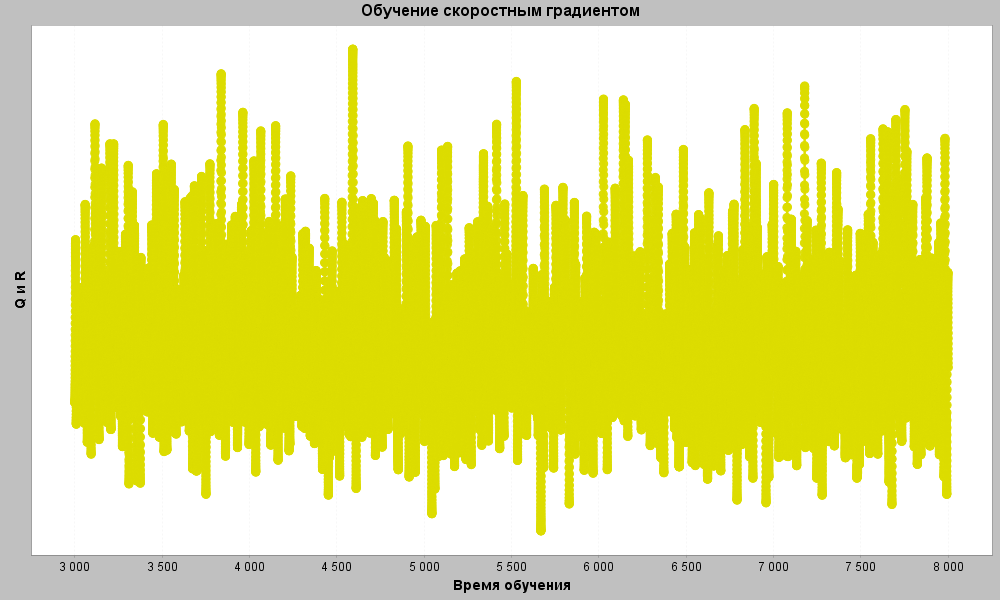

In [ ]:
velgrad_showQ(hopfield_double, t1 = 000, t2 = 10000, degree = 10, show_q = false)

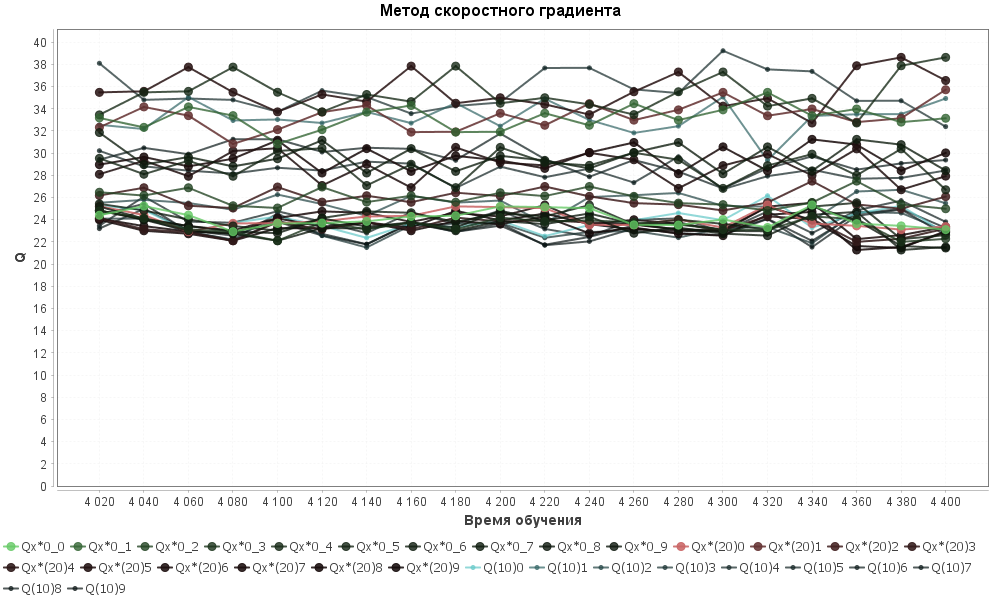

In [ ]:
test_velgrad_fit(hopfield_double, hopfield_errors, patterns_numbers, show_steps = 20, fit_steps = 20, bound = 1000)

И график динамики после обучения на произвольном векторе

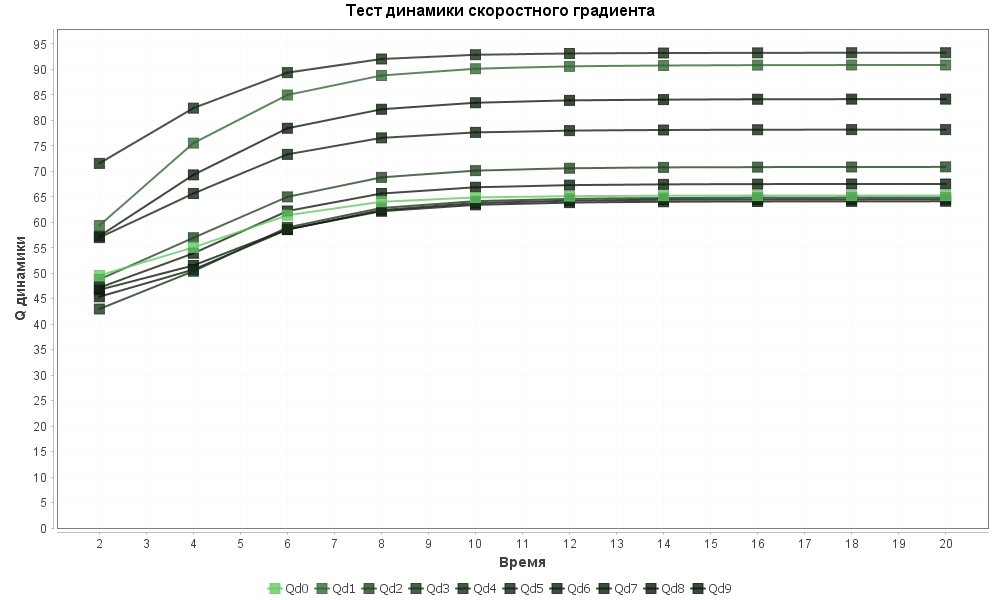

res268_0: HopfieldDynamic = ammonite.$sess.cmd5$Helper$HopfieldDynamic@20d5dd6e
res268_1: HopfieldModel = ammonite.$sess.cmd221$Helper$HopfieldModel@6c446f8c
res268_2: HopfieldDynamic = ammonite.$sess.cmd5$Helper$HopfieldDynamic@20d5dd6e

In [268]:
hopfield_double.dyn.set_time(0.0)
hopfield_double.move_fit_data(FitTypeMain.VelocityGradient, StepTypeMain.Dynamic)
hopfield_double.dyn.set_randomised_state(r1 = -1.0, r2 = 1.0)
display_patterns(Array(hopfield_double.dyn.get_x()), width_m, height_m, enc_m)
test_velgrad(hopfield_double, hopfield_errors, show_steps = 10, dynamic_steps =  2)
display_patterns(Array(hopfield_double.dyn.get_x()), width_m, height_m, enc_m)

Проверка стационарности

In [269]:
hopfield_double.dyn.set_time(0.0)
hopfield_double.move_fit_data(FitTypeMain.VelocityGradient, StepTypeMain.Dynamic)
test_patterns_with_view(hopfield_double, patterns_numbers, StepType.Dynamic, 100, width_m, height_m, enc_m, "After 100 steps", 100)


After 100 steps

res269_0: HopfieldDynamic = ammonite.$sess.cmd5$Helper$HopfieldDynamic@20d5dd6e
res269_1: HopfieldModel = ammonite.$sess.cmd221$Helper$HopfieldModel@6c446f8c

Проверка на изображениях

In [270]:
hopfield_double.dyn.set_time(0.0)
hopfield_double.move_fit_data(FitTypeMain.VelocityGradient, StepTypeMain.Dynamic)

display_patterns(patterns_numbers, width_m, height_m, enc_m)
display_patterns(patterns_numbers_error, width_m, height_m, enc_m)

test_patterns_with_view(hopfield_double, patterns_numbers_error, StepType.Dynamic, 1, width_m, height_m, enc_m, "After 1 step", 100)
test_patterns_with_view(hopfield_double, patterns_numbers_error, StepType.Dynamic, 5, width_m, height_m, enc_m, "After 5 steps", 100)
test_patterns_with_view(hopfield_double, patterns_numbers_error, StepType.Dynamic, 30, width_m, height_m, enc_m, "After 30 steps", 100)


After 1 step

After 5 steps

After 30 steps

res270_0: HopfieldDynamic = ammonite.$sess.cmd5$Helper$HopfieldDynamic@20d5dd6e
res270_1: HopfieldModel = ammonite.$sess.cmd221$Helper$HopfieldModel@6c446f8c

Выведем все числа на случай проверки

In [ ]:
show_velg(hopfield_double, hopfield_errors, 1000)

Fit Weights
	0,000000 0,000000 -0,000000 -0,000000 -0,000000 0,000000 -0,000000 -0,000000 -0,000000 -0,000000 -0,000000 0,000000 -0,000000 -0,000000 0,000000 0,000000 0,000000 -0,000000 -0,000000 0,000000 -0,000000 0,000000 -0,000000 -0,000000 0,000000 -0,000000 -0,000000 0,000000 -0,000000 0,000000 0,000000 0,000000 -0,000000 0,000000 -0,000000 -0,000000 0,000000 -0,000000 0,000000 -0,000000 -0,000000 -0,000000 ... 
	0,000000 0,000000 0,000000 0,000000 -0,000000 -0,000000 -0,000000 0,000000 0,000000 0,000000 0,000000 -0,000000 -0,000000 -0,000000 -0,000000 -0,000000 0,000000 0,000000 -0,000000 -0,000000 0,000000 -0,000000 -0,000000 0,000000 -0,000000 0,000000 0,000000 0,000000 -0,000000 -0,000000 -0,000000 0,000000 -0,000000 -0,000000 0,000000 -0,000000 -0,000000 0,000000 -0,000000 0,000000 0,000000 0,000000 ... 
	-0,000000 0,000000 0,000000 -0,000000 0,000000 0,000000 0,000000 -0,000000 -0,000000 -0,000000 -0,000000 0,000000 0,000000 0,000000 0,000000 0,000000 -0,000000 -0,000000 -0,

# Metrics